In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving 1776310869-P1-Retail Insights from Superstore Data.csv to 1776310869-P1-Retail Insights from Superstore Data.csv


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [7]:
# Load dataset
df = pd.read_csv("1776310869-P1-Retail Insights from Superstore Data.csv")

# Display first 5 rows
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [8]:
# Dataset dimensions
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Info:")
df.info()

Dataset Shape: (9994, 13)

Columns:
['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory u

In [9]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Check data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate Rows: 17

Data Types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [10]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9977.000000,9977.000000,9977.000000,9977.000000,9977.00000
mean,55154.964117,230.148902,3.790719,0.156278,28.69013
std,32058.266816,623.721409,2.226657,0.206455,234.45784
min,1040.000000,0.444000,1.000000,0.000000,-6599.97800
25%,23223.000000,17.300000,2.000000,0.000000,1.72620
50%,55901.000000,54.816000,3.000000,0.200000,8.67100
75%,90008.000000,209.970000,5.000000,0.200000,29.37200
max,99301.000000,22638.480000,14.000000,0.800000,8399.97600


In [11]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity Sold:", total_quantity)

Total Sales: 2296195.5903
Total Profit: 286241.4226
Total Quantity Sold: 37820


Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


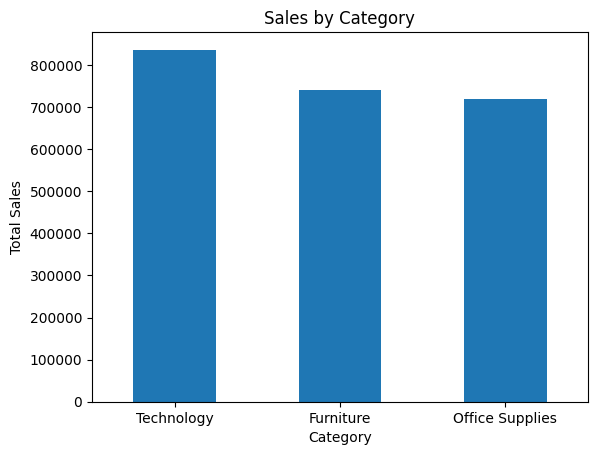

In [15]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64


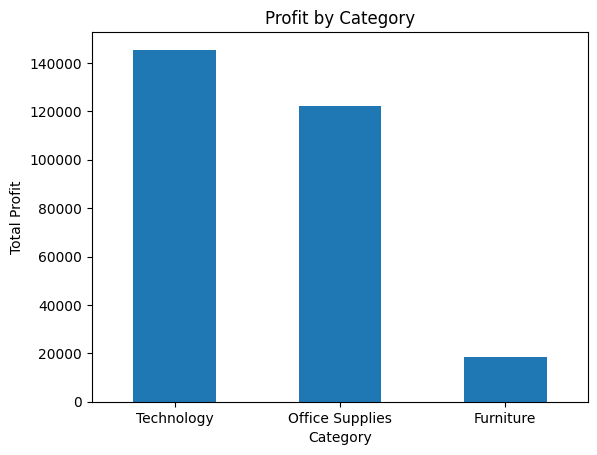

In [16]:
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.show()

Sub-Category
Phones         330007.0540
Chairs         327777.7610
Storage        223843.6080
Tables         206965.5320
Binders        203409.1690
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91683.0240
Paper           78224.1420
Supplies        46673.5380
Art             27107.0320
Envelopes       16476.4020
Labels          12444.9120
Fasteners        3024.2800
Name: Sales, dtype: float64


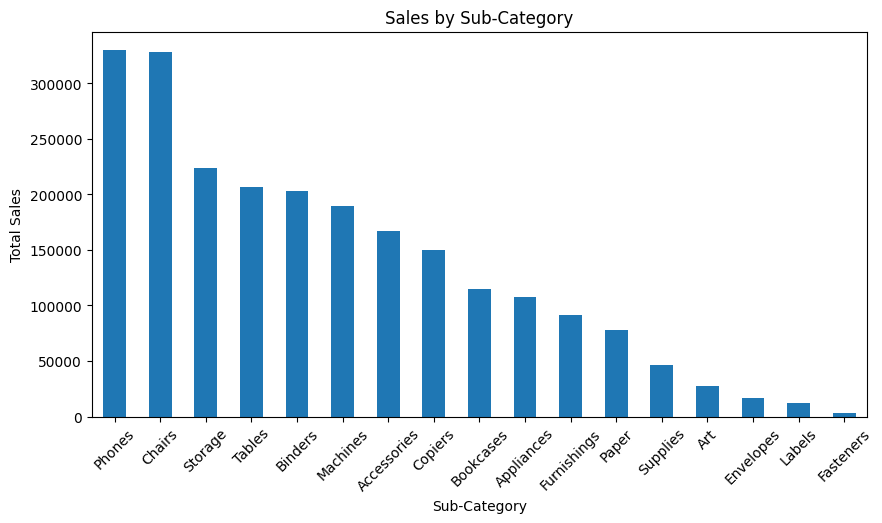

In [17]:
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(subcategory_sales)

subcategory_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5526.3820
Art             6524.6118
Envelopes       6964.1767
Furnishings    13052.7230
Appliances     18138.0054
Storage        21278.8264
Chairs         26567.1278
Binders        30228.0003
Paper          33944.2395
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


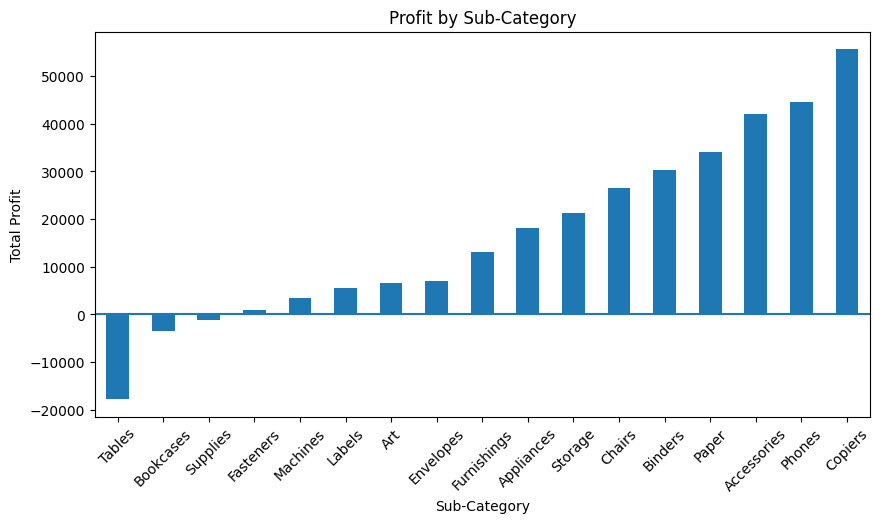

In [18]:
subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)

print(subcategory_profit)

subcategory_profit.plot(kind="bar", figsize=(10, 5))

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)

plt.axhline(y=0)

plt.show()

Region
West       725255.6365
East       678435.1960
Central    500782.8528
South      391721.9050
Name: Sales, dtype: float64


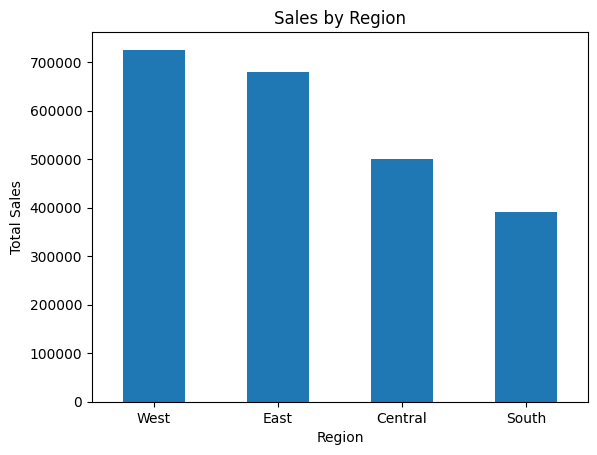

In [19]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

Region
West       108329.8079
East        91506.3092
South       46749.4303
Central     39655.8752
Name: Profit, dtype: float64


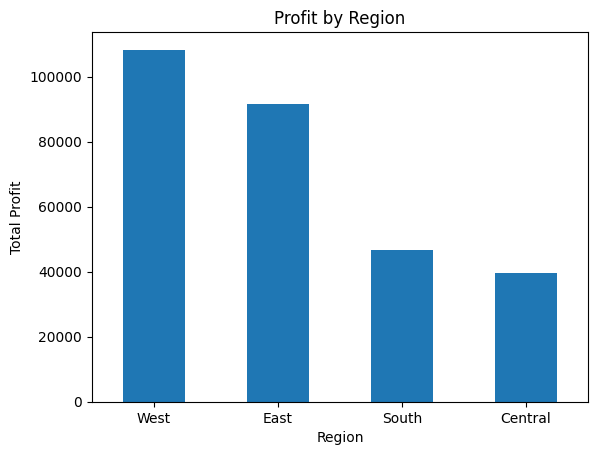

In [20]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(region_profit)

region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.show()

State
California      457576.2715
New York        310827.1510
Texas           170124.5418
Washington      138560.8100
Pennsylvania    116496.3620
Florida          89473.7080
Illinois         80162.5370
Ohio             77976.7640
Michigan         75879.6440
Virginia         70636.7200
Name: Sales, dtype: float64


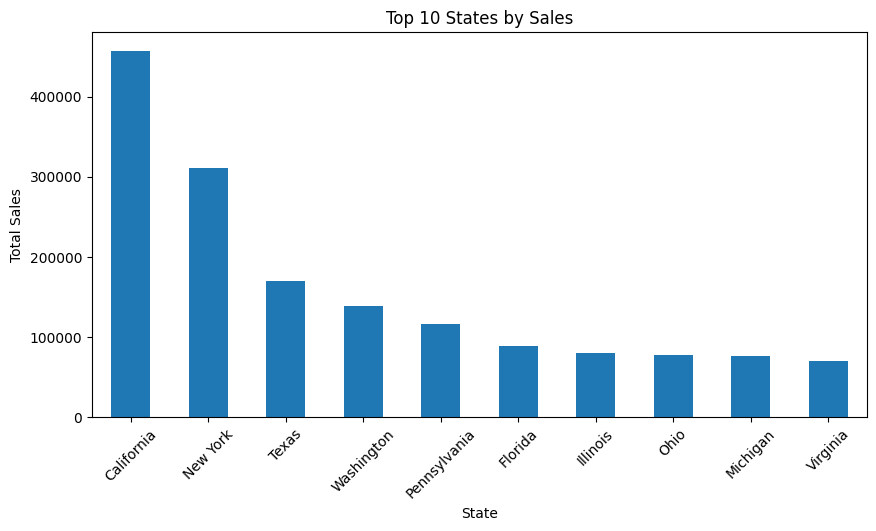

In [21]:
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(state_sales)

state_sales.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

State
California    76330.7891
New York      74015.4622
Washington    33368.2375
Michigan      24428.0903
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


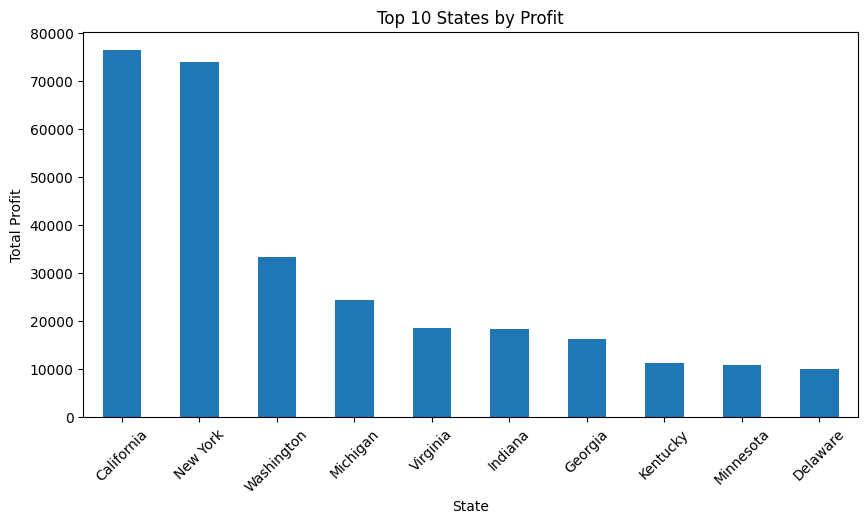

In [22]:
state_profit = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(state_profit)

state_profit.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)

plt.show()

Segment
Consumer       1.160833e+06
Corporate      7.060701e+05
Home Office    4.292927e+05
Name: Sales, dtype: float64


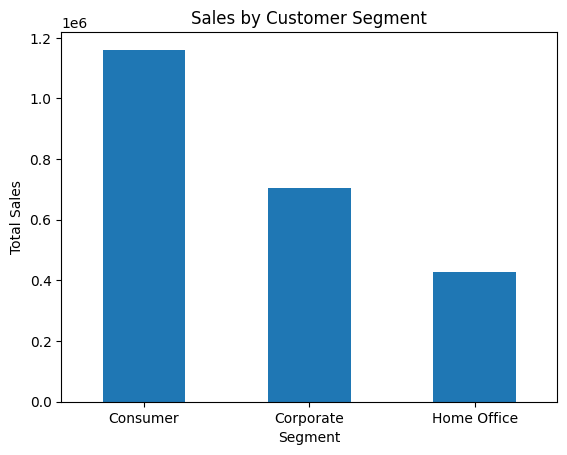

In [23]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)

segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

Segment
Consumer       134007.4413
Corporate       91954.9798
Home Office     60279.0015
Name: Profit, dtype: float64


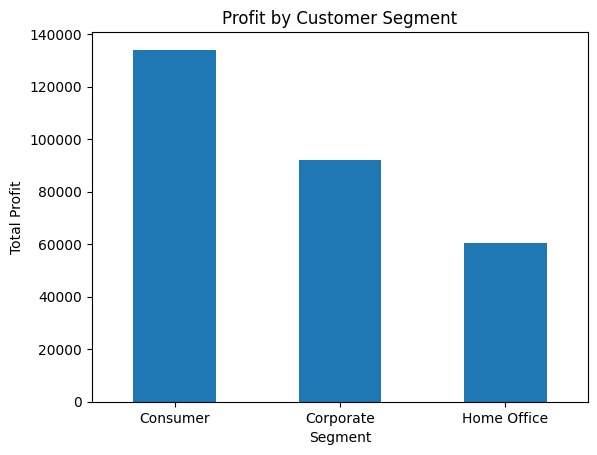

In [25]:
segment_profit = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_profit)

segment_profit.plot(kind="bar")

plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.show()

Discount
0.00     67.024108
0.10     96.055074
0.15     27.288298
0.20     24.721217
0.30    -45.828401
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -102.116395
Name: Profit, dtype: float64


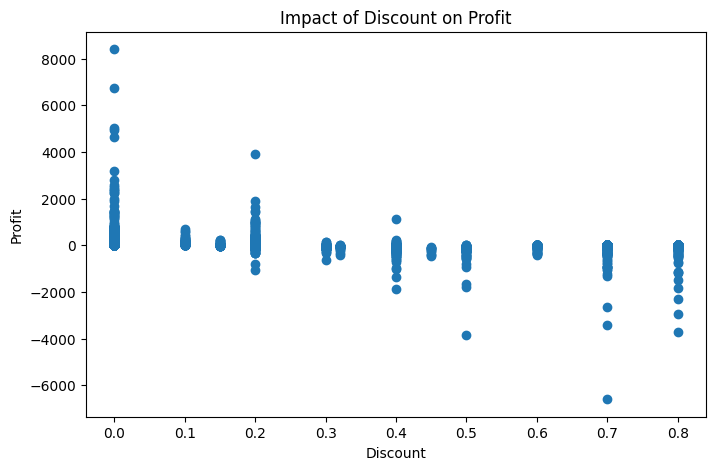

In [26]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .mean()
)

print(discount_profit)

plt.figure(figsize=(8, 5))

plt.scatter(df["Discount"], df["Profit"])

plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

In [27]:
numeric_columns = df.select_dtypes(include=["number"])

correlation = numeric_columns.corr()

print(correlation)

             Postal Code     Sales  Quantity  Discount    Profit
Postal Code     1.000000 -0.023476  0.013110  0.059225 -0.029892
Sales          -0.023476  1.000000  0.200722 -0.028311  0.479067
Quantity        0.013110  0.200722  1.000000  0.008678  0.066211
Discount        0.059225 -0.028311  0.008678  1.000000 -0.219662
Profit         -0.029892  0.479067  0.066211 -0.219662  1.000000


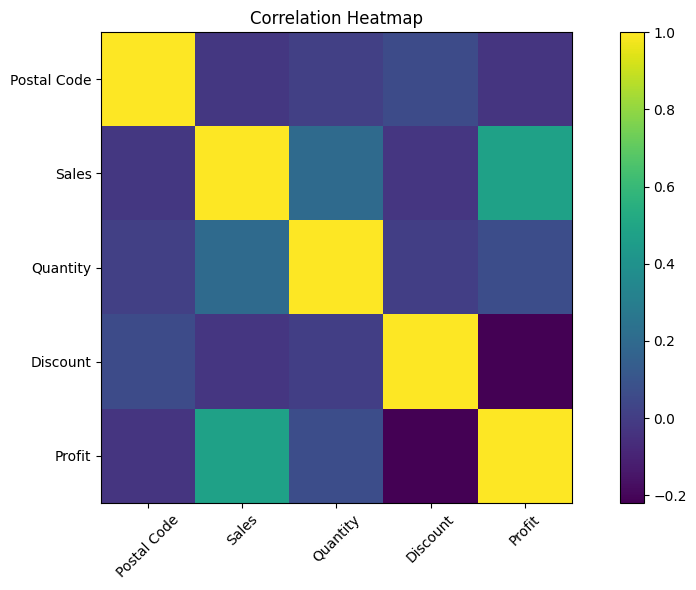

In [28]:
plt.figure(figsize=(10, 6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [29]:
print("========== RETAIL BUSINESS INSIGHTS ==========\n")

print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Quantity:", df["Quantity"].sum())

print("\nHighest Sales Category:")
print(df.groupby("Category")["Sales"].sum().idxmax())

print("\nHighest Profit Category:")
print(df.groupby("Category")["Profit"].sum().idxmax())

print("\nMost Profitable Region:")
print(df.groupby("Region")["Profit"].sum().idxmax())

print("\nHighest Sales Segment:")
print(df.groupby("Segment")["Sales"].sum().idxmax())

print("\nLeast Profitable Sub-Category:")
print(df.groupby("Sub-Category")["Profit"].sum().idxmin())

print("\nMost Profitable Sub-Category:")
print(df.groupby("Sub-Category")["Profit"].sum().idxmax())

========== RETAIL BUSINESS INSIGHTS ==========

Total Sales: 2296195.59
Total Profit: 286241.42
Total Quantity: 37820

Highest Sales Category:
Technology

Highest Profit Category:
Technology

Most Profitable Region:
West

Highest Sales Segment:
Consumer

Least Profitable Sub-Category:
Tables

Most Profitable Sub-Category:
Copiers


In [30]:
df.to_csv("cleaned_superstore_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [31]:
import os
import zipfile
import matplotlib.pyplot as plt

# Create a folder to save all charts
os.makedirs("superstore_charts", exist_ok=True)

# -----------------------------
# 1. SALES BY CATEGORY
# -----------------------------
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("superstore_charts/01_sales_by_category.png", dpi=300)
plt.close()


# -----------------------------
# 2. PROFIT BY CATEGORY
# -----------------------------
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("superstore_charts/02_profit_by_category.png", dpi=300)
plt.close()


# -----------------------------
# 3. SALES BY SUB-CATEGORY
# -----------------------------
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
subcategory_sales.plot(kind="bar")
plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("superstore_charts/03_sales_by_subcategory.png", dpi=300)
plt.close()


# -----------------------------
# 4. PROFIT BY SUB-CATEGORY
# -----------------------------
subcategory_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()

plt.figure(figsize=(12, 6))
subcategory_profit.plot(kind="bar")
plt.axhline(y=0)
plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("superstore_charts/04_profit_by_subcategory.png", dpi=300)
plt.close()


# -----------------------------
# 5. SALES BY REGION
# -----------------------------
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("superstore_charts/05_sales_by_region.png", dpi=300)
plt.close()


# -----------------------------
# 6. PROFIT BY REGION
# -----------------------------
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("superstore_charts/06_profit_by_region.png", dpi=300)
plt.close()


# -----------------------------
# 7. TOP 10 STATES BY SALES
# -----------------------------
top_states_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_states_sales.plot(kind="bar")
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("superstore_charts/07_top_10_states_sales.png", dpi=300)
plt.close()


# -----------------------------
# 8. TOP 10 STATES BY PROFIT
# -----------------------------
top_states_profit = (
    df.groupby("State")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_states_profit.plot(kind="bar")
plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("superstore_charts/08_top_10_states_profit.png", dpi=300)
plt.close()


# -----------------------------
# 9. SALES BY SEGMENT
# -----------------------------
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
segment_sales.plot(kind="bar")
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("superstore_charts/09_sales_by_segment.png", dpi=300)
plt.close()


# -----------------------------
# 10. PROFIT BY SEGMENT
# -----------------------------
segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
segment_profit.plot(kind="bar")
plt.title("Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("superstore_charts/10_profit_by_segment.png", dpi=300)
plt.close()


# -----------------------------
# 11. DISCOUNT VS PROFIT
# -----------------------------
plt.figure(figsize=(10, 6))
plt.scatter(df["Discount"], df["Profit"])
plt.title("Impact of Discount on Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.savefig("superstore_charts/11_discount_vs_profit.png", dpi=300)
plt.close()


# -----------------------------
# 12. CORRELATION HEATMAP
# -----------------------------
numeric_df = df.select_dtypes(include=["number"])
correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation)
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("superstore_charts/12_correlation_heatmap.png", dpi=300)
plt.close()


# -----------------------------
# CREATE ZIP FILE
# -----------------------------
with zipfile.ZipFile(
    "superstore_charts.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file in os.listdir("superstore_charts"):
        file_path = os.path.join("superstore_charts", file)
        zip_file.write(file_path, arcname=file)


print("All images created successfully!")
print("ZIP file created: superstore_charts.zip")

All images created successfully!
ZIP file created: superstore_charts.zip
